In [23]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.19.0


In [24]:
# Descargar el conjunto de datos CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalizar los valores de los píxeles para que estén entre 0 y 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Nombres de las clases para referencia
class_names = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

print(f"Imágenes de entrenamiento: {train_images.shape}")
print(f"Imágenes de prueba: {test_images.shape}")

Imágenes de entrenamiento: (50000, 32, 32, 3)
Imágenes de prueba: (10000, 32, 32, 3)


## Modelo 1
CNN base con 3 capas convolucionales (32-64-64), `MaxPooling2D`, `Flatten`, una capa densa de 64 y salida `softmax`.

In [25]:
model = models.Sequential()

# Primera capa convolucional
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Segunda capa convolucional
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Tercera capa convolucional
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Aplanar los resultados para pasarlos a una red neuronal tradicional
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Capa de salida con 10 neuronas (una por cada clase)
model.add(layers.Dense(10, activation='softmax'))

# Ver el resumen de la arquitectura
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:

history = model.fit(train_images, train_labels, epochs=15,
                    validation_split=0.1)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4216 - loss: 1.5780 - val_accuracy: 0.5140 - val_loss: 1.3532
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5731 - loss: 1.2077 - val_accuracy: 0.6042 - val_loss: 1.1071
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6289 - loss: 1.0583 - val_accuracy: 0.6532 - val_loss: 1.0047
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6617 - loss: 0.9664 - val_accuracy: 0.6742 - val_loss: 0.9425
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6858 - loss: 0.8934 - val_accuracy: 0.6780 - val_loss: 0.9421
Epoch 6/15
 227/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6968 - loss: 0.8445

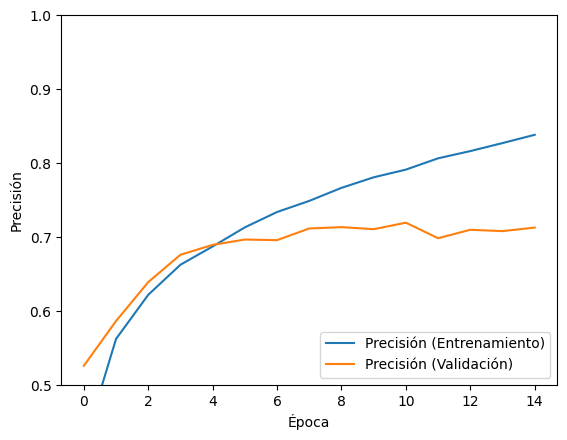

313/313 - 2s - 5ms/step - accuracy: 0.7024 - loss: 1.0450

Precisión en los datos de prueba: 0.70


In [ ]:
# Graficar la precisión de entrenamiento y validación
plt.plot(history.history['accuracy'], label='Precisión (Entrenamiento)')
plt.plot(history.history['val_accuracy'], label='Precisión (Validación)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

# Evaluar con los datos de prueba
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nPrecisión en los datos de prueba: {test_acc:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


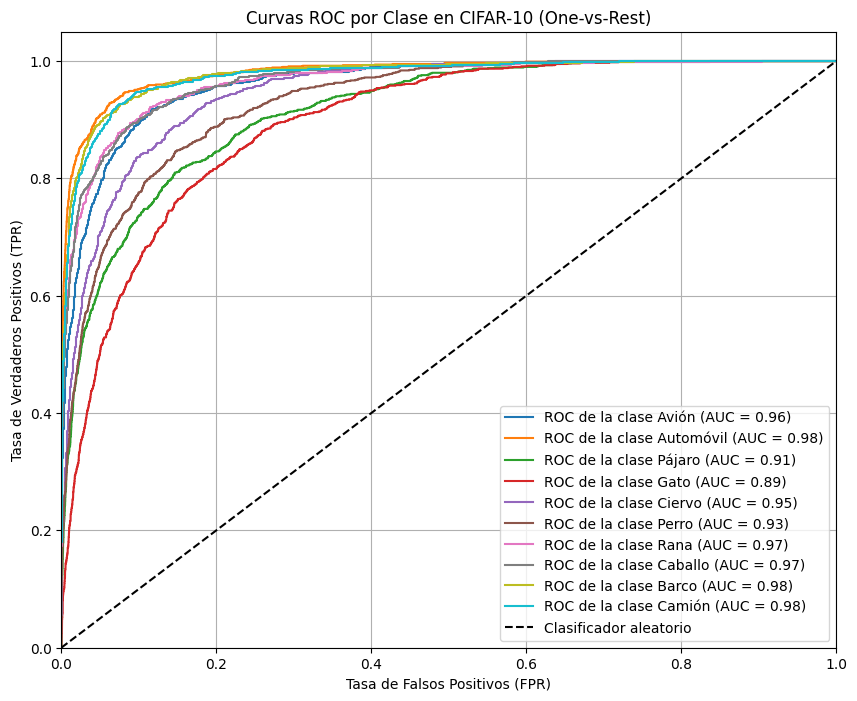

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

predictions = model.predict(test_images)

# Convertir las etiquetas verdaderas a formato one-hot para el cálculo de la curva ROC multiclase
label_binarizer = LabelBinarizer()
y_true_one_hot = label_binarizer.fit_transform(test_labels)

# Calcular la curva ROC y el área bajo la curva (AUC) para cada clase
n_classes = len(class_names)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotear las curvas ROC para cada clase
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC de la clase {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC por Clase en CIFAR-10 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Modelo 2
Misma base del Modelo 1 con `Dropout(0.3)` antes de la capa de salida para mejorar regularización.

In [ ]:
new_model = models.Sequential()

# Primera capa convolucional
new_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
new_model.add(layers.MaxPooling2D((2, 2)))

# Segunda capa convolucional
new_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
new_model.add(layers.MaxPooling2D((2, 2)))

# Tercera capa convolucional
new_model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Aplanar los resultados para pasarlos a una red neuronal tradicional
new_model.add(layers.Flatten())
new_model.add(layers.Dense(64, activation='relu'))

# Capa de Dropout para regularización
new_model.add(layers.Dropout(0.3))

# Capa de salida con 10 neuronas (una por cada clase)
new_model.add(layers.Dense(10, activation='softmax'))

# Ver el resumen de la arquitectura
new_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
new_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("New model compiled successfully.")

New model compiled successfully.


In [ ]:
history_new_model = new_model.fit(train_images, train_labels, epochs=15, validation_split=0.1)
print("New model training complete.")

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3907 - loss: 1.6570 - val_accuracy: 0.5288 - val_loss: 1.3192
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5276 - loss: 1.3240 - val_accuracy: 0.5940 - val_loss: 1.1433
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5806 - loss: 1.1867 - val_accuracy: 0.6348 - val_loss: 1.0397
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6199 - loss: 1.0857 - val_accuracy: 0.6434 - val_loss: 1.0256
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6494 - loss: 1.0058 - val_accuracy: 0.6788 - val_loss: 0.9187
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6654 - loss: 0.9473 - val_accuracy: 0.6936 - val_loss: 0.8803
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6862 - loss: 0.8921 - val_accuracy: 0.6770 - val_loss: 0.9338
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7005 - loss: 0.8499 -

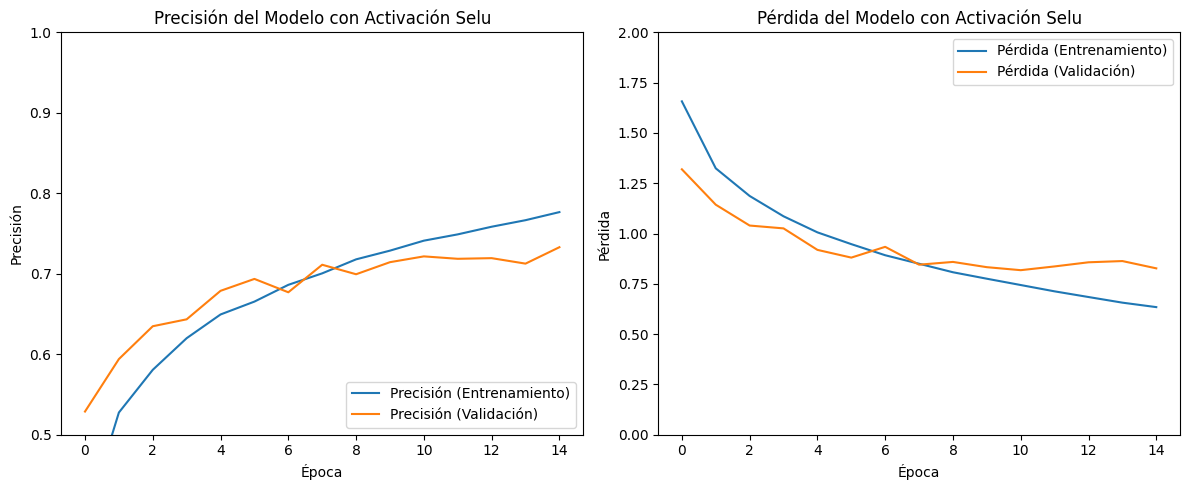

313/313 - 1s - 4ms/step - accuracy: 0.7153 - loss: 0.8807

Precisión en los datos de prueba (Modelo Selu): 0.72


In [ ]:
import matplotlib.pyplot as plt

# Graficar la precisión de entrenamiento y validación para el nuevo modelo con Selu
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_new_model.history['accuracy'], label='Precisión (Entrenamiento)')
plt.plot(history_new_model.history['val_accuracy'], label='Precisión (Validación)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Precisión del Modelo con Activación Selu')

# Graficar la pérdida de entrenamiento y validación para el nuevo modelo con Selu
plt.subplot(1, 2, 2)
plt.plot(history_new_model.history['loss'], label='Pérdida (Entrenamiento)')
plt.plot(history_new_model.history['val_loss'], label='Pérdida (Validación)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.ylim([0, 2])
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo con Activación Selu')

plt.tight_layout()
plt.show()

# Evaluar el nuevo modelo con los datos de prueba
test_loss_selu, test_acc_selu = new_model.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en los datos de prueba (Modelo Selu): {test_acc_selu:.2f}')

## Modelo 3
Arquitectura similar al Modelo 1, reemplazando activaciones `relu` por `selu` en capas convolucionales y densas.

In [ ]:
new_model_selu = models.Sequential()

# Primera capa convolucional con 'selu'
new_model_selu.add(layers.Conv2D(32, (3, 3), activation='selu', input_shape=(32, 32, 3)))
new_model_selu.add(layers.MaxPooling2D((2, 2)))

# Segunda capa convolucional con 'selu'
new_model_selu.add(layers.Conv2D(64, (3, 3), activation='selu'))
new_model_selu.add(layers.MaxPooling2D((2, 2)))

# Tercera capa convolucional con 'selu'
new_model_selu.add(layers.Conv2D(64, (3, 3), activation='selu'))

# Aplanar los resultados
new_model_selu.add(layers.Flatten())
new_model_selu.add(layers.Dense(64, activation='selu'))

# Capa de salida con 'softmax'
new_model_selu.add(layers.Dense(10, activation='softmax'))

# Ver el resumen de la arquitectura
new_model_selu.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
new_model_selu.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("New model with Selu activation compiled successfully.")

New model with Selu activation compiled successfully.


In [ ]:
history_new_model_selu = new_model_selu.fit(train_images, train_labels, epochs=15, validation_split=0.1)
print("New model with Selu activation training complete.")

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4859 - loss: 1.4551 - val_accuracy: 0.5682 - val_loss: 1.2145
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5768 - loss: 1.2006 - val_accuracy: 0.6022 - val_loss: 1.1287
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6262 - loss: 1.0648 - val_accuracy: 0.6422 - val_loss: 1.0286
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6595 - loss: 0.9705 - val_accuracy: 0.6722 - val_loss: 0.9572
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6857 - loss: 0.9017 - val_accuracy: 0.6682 - val_loss: 0.9549
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7080 - loss: 0.8383 - val_accuracy: 0.6772 - val_loss: 0.9598
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7263 - loss: 0.7821 - val_accuracy: 0.6752 - val_loss: 0.9810
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7464 - loss: 0.7262 -

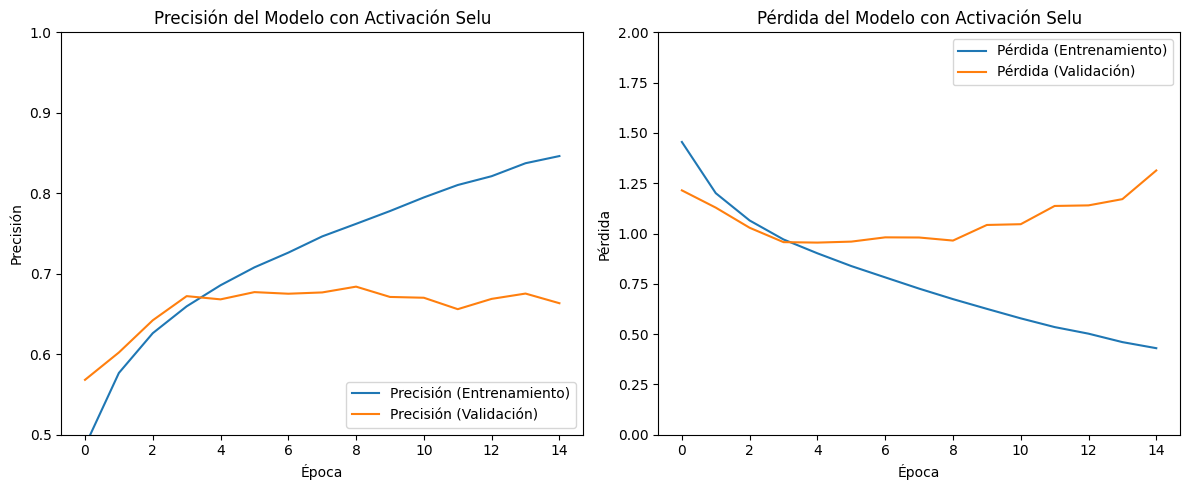

313/313 - 1s - 3ms/step - accuracy: 0.6470 - loss: 1.4108

Precisión en los datos de prueba (Modelo Selu): 0.65


In [ ]:
import matplotlib.pyplot as plt

# Graficar la precisión de entrenamiento y validación para el nuevo modelo con Selu
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_new_model_selu.history['accuracy'], label='Precisión (Entrenamiento)')
plt.plot(history_new_model_selu.history['val_accuracy'], label='Precisión (Validación)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Precisión del Modelo con Activación Selu')

# Graficar la pérdida de entrenamiento y validación para el nuevo modelo con Selu
plt.subplot(1, 2, 2)
plt.plot(history_new_model_selu.history['loss'], label='Pérdida (Entrenamiento)')
plt.plot(history_new_model_selu.history['val_loss'], label='Pérdida (Validación)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.ylim([0, 2])
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo con Activación Selu')

plt.tight_layout()
plt.show()

# Evaluar el nuevo modelo con los datos de prueba
test_loss_selu, test_acc_selu = new_model_selu.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en los datos de prueba (Modelo Selu): {test_acc_selu:.2f}')

## Modelo 4
CNN con mayor capacidad: más filtros en convoluciones intermedias y una capa densa adicional con regularización por `Dropout`.

In [ ]:
model_modified = models.Sequential()

# Primera capa convolucional con relu
model_modified.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_modified.add(layers.MaxPooling2D((2, 2)))

# Segunda capa convolucional con 128 filtros y selu
model_modified.add(layers.Conv2D(128, (3, 3), activation='selu'))
model_modified.add(layers.MaxPooling2D((2, 2)))

# Tercera capa convolucional con 128 filtros y selu
model_modified.add(layers.Conv2D(128, (3, 3), activation='selu'))

# Aplanar los resultados
model_modified.add(layers.Flatten())
model_modified.add(layers.Dense(64, activation='selu'))

# Capa Dense adicional con selu
model_modified.add(layers.Dense(64, activation='selu'))

# Capa de Dropout para regularización
model_modified.add(layers.Dropout(0.3))

# Capa de salida con 10 neuronas (una por cada clase) y softmax
model_modified.add(layers.Dense(10, activation='softmax'))

# Ver el resumen de la arquitectura
model_modified.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,418 (1.23 MB)

 Trainable params: 321,418 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_modified.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Modified model compiled successfully.")

Modified model compiled successfully.


In [ ]:
history_model_modified = model_modified.fit(train_images, train_labels, epochs=10, validation_split=0.1)
print("Modified model training complete.")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8995 - loss: 0.2910 - val_accuracy: 0.6646 - val_loss: 1.4166
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9087 - loss: 0.2652 - val_accuracy: 0.6674 - val_loss: 1.5236
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9118 - loss: 0.2541 - val_accuracy: 0.6800 - val_loss: 1.5124
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9194 - loss: 0.2385 - val_accuracy: 0.6584 - val_loss: 1.7701
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9219 - loss: 0.2338 - val_accuracy: 0.6676 - val_loss: 1.6133
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9263 - loss: 0.2190 - val_accuracy: 0.6576 - val_loss: 1.7611
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9288 - loss: 0.2123 - val_accuracy: 0.6662 - val_loss: 1.6583
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9329 - loss: 0.1993 -

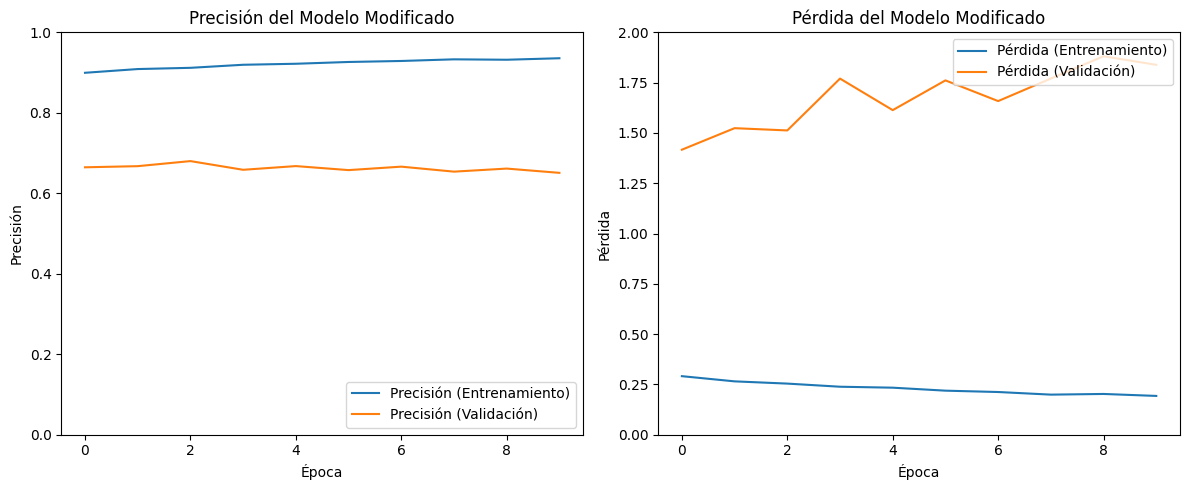

313/313 - 2s - 6ms/step - accuracy: 0.6414 - loss: 1.9568

Precisión en los datos de prueba (Modelo Modificado): 0.64


In [ ]:
import matplotlib.pyplot as plt

# Graficar la precisión de entrenamiento y validación para el modelo modificado
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_model_modified.history['accuracy'], label='Precisión (Entrenamiento)')
plt.plot(history_model_modified.history['val_accuracy'], label='Precisión (Validación)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right')
plt.title('Precisión del Modelo Modificado')

# Graficar la pérdida de entrenamiento y validación para el modelo modificado
plt.subplot(1, 2, 2)
plt.plot(history_model_modified.history['loss'], label='Pérdida (Entrenamiento)')
plt.plot(history_model_modified.history['val_loss'], label='Pérdida (Validación)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.ylim([0, 2])
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo Modificado')

plt.tight_layout()
plt.show()

# Evaluar el nuevo modelo con los datos de prueba
test_loss_modified, test_acc_modified = model_modified.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en los datos de prueba (Modelo Modificado): {test_acc_modified:.2f}')

## Modelo 5
CNN profunda con bloques convolucionales más anchos, normalización por lotes y regularización para estabilizar entrenamiento.

In [ ]:
from tensorflow.keras import regularizers, callbacks
from tensorflow.keras import Input, Model

# Aumentación de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
])

def build_strong_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Bloque 1
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x)

    # Bloque 3
    x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='strong_cnn_cifar10')

strong_cnn = build_strong_cnn()

try:
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1)
except TypeError:
    print("Tu versión no soporta label_smoothing en SparseCategoricalCrossentropy; se usará la pérdida estándar.")
    loss_fn = 'sparse_categorical_crossentropy'

strong_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
 )

strong_cnn.summary()

Tu versión no soporta label_smoothing en SparseCategoricalCrossentropy; se usará la pérdida estándar.


Model: "strong_cnn_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,218,378 (4.65 MB)

 Trainable params: 1,216,074 (4.64 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
cb_early = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_strong = strong_cnn.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[cb_early, cb_reduce_lr],
    verbose=1
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.6868 - loss: 1.1902 - val_accuracy: 0.6514 - val_loss: 1.2805 - learning_rate: 0.0010
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.7094 - loss: 1.1082 - val_accuracy: 0.6688 - val_loss: 1.2151 - learning_rate: 0.0010
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7264 - loss: 1.0586 - val_accuracy: 0.6560 - val_loss: 1.2800 - learning_rate: 0.0010
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7389 - loss: 1.0184 - val_accuracy: 0.7554 - val_loss: 0.9722 - learning_rate: 0.0010
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7521 - loss: 0.9940 - val_accuracy: 0.6006 - val_loss: 1.5290 - learning_rate: 0.0010
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7578 - loss: 0.9749 - val_accuracy: 0.7134 - val_loss: 1.2076 - learning_rate: 0.0010
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7673 - l

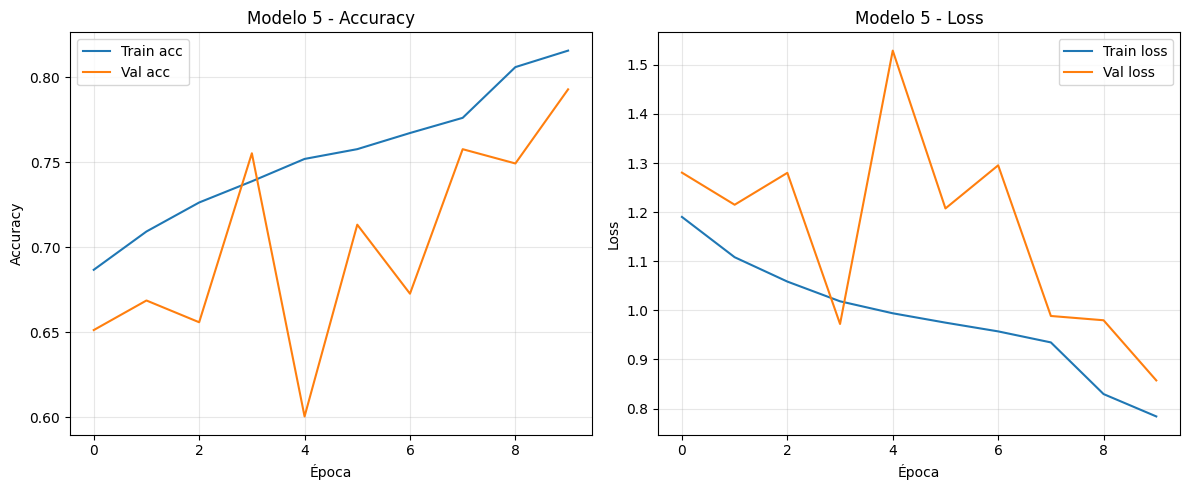

313/313 - 2s - 7ms/step - accuracy: 0.7813 - loss: 0.9015
Precisión en test (Modelo 5): 0.7813

Comparación de accuracies disponibles:
- Modelo 5 (Strong CNN): 0.7813


In [ ]:
# Curvas de entrenamiento - Modelo 5
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_strong.history['accuracy'], label='Train acc')
plt.plot(history_strong.history['val_accuracy'], label='Val acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Modelo 5 - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_strong.history['loss'], label='Train loss')
plt.plot(history_strong.history['val_loss'], label='Val loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Modelo 5 - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_strong, test_acc_strong = strong_cnn.evaluate(test_images, test_labels, verbose=2)
print(f'Precisión en test (Modelo 5): {test_acc_strong:.4f}')

## Modelo 7
CNN clásica mejorada con dos bloques convolucionales, `Dropout` intermedio y una capa densa de 256 antes de `softmax`.

In [ ]:
# Definición del modelo (solo capas ya vistas)
model7 = models.Sequential()

model7.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model7.add(layers.Conv2D(32, (3, 3), activation='relu'))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.Dropout(0.25))

model7.add(layers.Conv2D(64, (3, 3), activation='relu'))
model7.add(layers.Conv2D(64, (3, 3), activation='relu'))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.Dropout(0.25))

model7.add(layers.Flatten())
model7.add(layers.Dense(256, activation='relu'))
model7.add(layers.Dropout(0.5))
model7.add(layers.Dense(10, activation='softmax'))

model7.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model7.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,994 (1.82 MB)

 Trainable params: 477,994 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del Modelo 7 con callbacks ya usados
cb_early_7 = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr_7 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_model7 = model7.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[cb_early_7, cb_reduce_lr_7],
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.3470 - loss: 1.7588 - val_accuracy: 0.4886 - val_loss: 1.4370 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5088 - loss: 1.3620 - val_accuracy: 0.5730 - val_loss: 1.1750 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5779 - loss: 1.1849 - val_accuracy: 0.6428 - val_loss: 1.0079 - learning_rate: 0.0010
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6210 - loss: 1.0761 - val_accuracy: 0.6678 - val_loss: 0.9249 - learning_rate: 0.0010
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6498 - loss: 0.9939 - val_accuracy: 0.6982 - val_loss: 0.8425 - learning_rate: 0.0010
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6763 - loss: 0.9189 - val_accuracy: 0.7044 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6915 - loss: 0.8763 

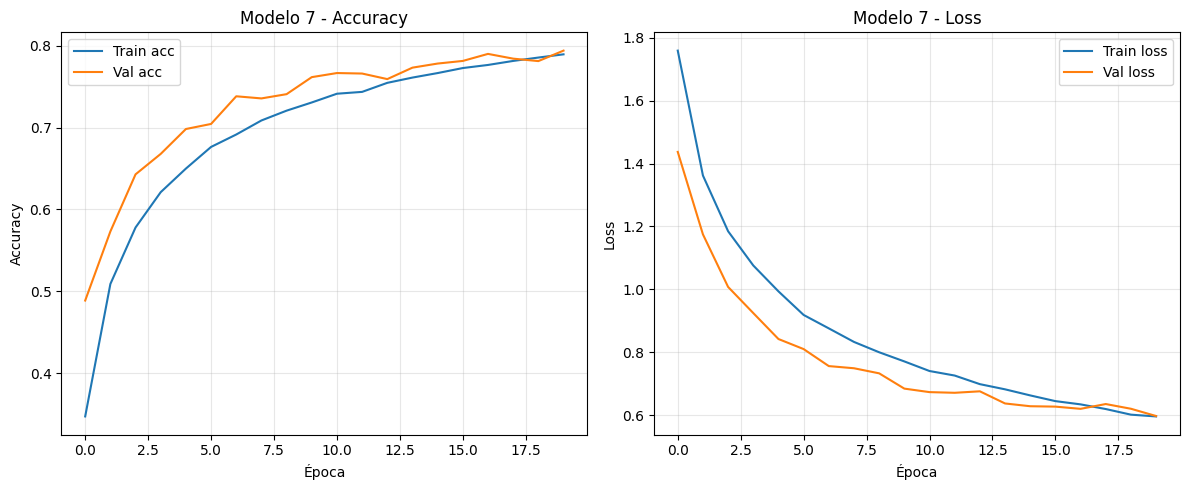

313/313 - 3s - 8ms/step - accuracy: 0.1125 - loss: 2.3032
Precisión en test (Modelo 7): 0.1125

Comparación de accuracies disponibles:
- test_acc_resnet: 0.8138
- test_acc_strong: 0.7813
- test_acc_model7: 0.1125


In [ ]:
# Curvas y evaluación del Modelo 7
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_model7.history['accuracy'], label='Train acc')
plt.plot(history_model7.history['val_accuracy'], label='Val acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Modelo 7 - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_model7.history['loss'], label='Train loss')
plt.plot(history_model7.history['val_loss'], label='Val loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Modelo 7 - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_model7, test_acc_model7 = model7.evaluate(test_images, test_labels, verbose=2)
print(f'Precisión en test (Modelo 7): {test_acc_model7:.4f}')

## Modelo 8
CNN tipo VGG compacta: bloques 64-128-256, normalización por lotes y `Dropout` progresivo para mejor generalización.

In [ ]:
# Definición del Modelo 8 (solo temas vistos)
model8 = models.Sequential()

model8.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model8.add(layers.BatchNormalization())
model8.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model8.add(layers.BatchNormalization())
model8.add(layers.MaxPooling2D((2, 2)))
model8.add(layers.Dropout(0.25))

model8.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model8.add(layers.BatchNormalization())
model8.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model8.add(layers.BatchNormalization())
model8.add(layers.MaxPooling2D((2, 2)))
model8.add(layers.Dropout(0.35))

model8.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
model8.add(layers.BatchNormalization())
model8.add(layers.MaxPooling2D((2, 2)))
model8.add(layers.Dropout(0.4))

model8.add(layers.Flatten())
model8.add(layers.Dense(256, activation='relu'))
model8.add(layers.Dropout(0.5))
model8.add(layers.Dense(10, activation='softmax'))

model8.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model8.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,609,290 (6.14 MB)

 Trainable params: 1,608,010 (6.13 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Entrenamiento del Modelo 8
cb_early_8 = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr_8 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_model8 = model8.fit(
    train_images, train_labels,
    epochs=25,
    batch_size=128,
    validation_split=0.1,
    callbacks=[cb_early_8, cb_reduce_lr_8],
    verbose=1
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.3419 - loss: 1.8561 - val_accuracy: 0.1874 - val_loss: 2.9333 - learning_rate: 0.0010
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5012 - loss: 1.3867 - val_accuracy: 0.6006 - val_loss: 1.1558 - learning_rate: 0.0010
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5877 - loss: 1.1719 - val_accuracy: 0.5672 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6418 - loss: 1.0271 - val_accuracy: 0.6252 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6771 - loss: 0.9283 - val_accuracy: 0.7196 - val_loss: 0.7972 - learning_rate: 0.0010
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7037 - loss: 0.8610 - val_accuracy: 0.7580 - val_loss: 0.7325 - learning_rate: 0.0010
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7290 - loss: 0

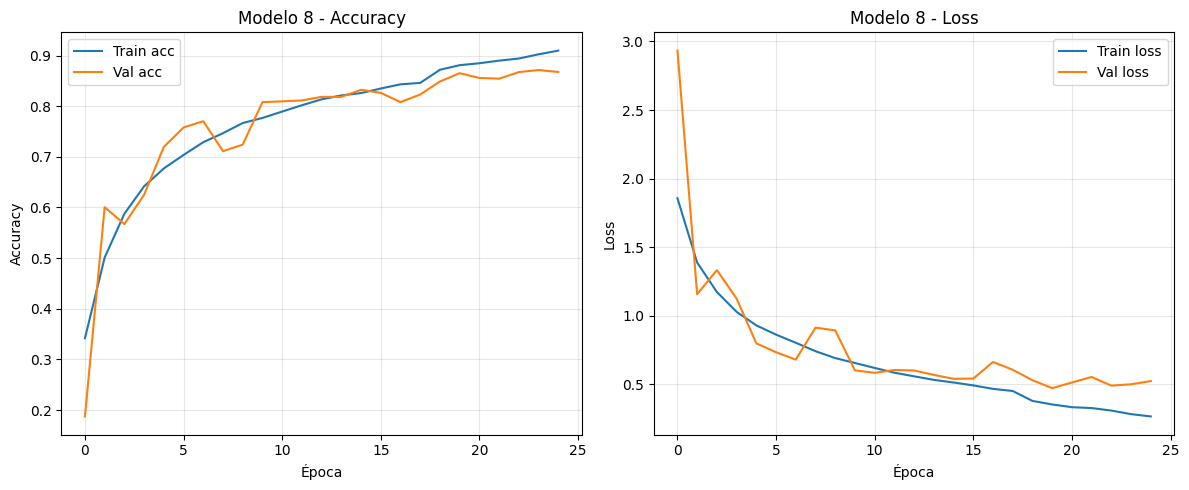

313/313 - 3s - 10ms/step - accuracy: 0.8628 - loss: 0.5127
Precisión en test (Modelo 8): 0.8628

Comparación de accuracies disponibles:
- test_acc_model8: 0.8628
- test_acc_resnet: 0.8138
- test_acc_strong: 0.7813
- test_acc_model7: 0.1125


In [ ]:
# Curvas y evaluación del Modelo 8
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_model8.history['accuracy'], label='Train acc')
plt.plot(history_model8.history['val_accuracy'], label='Val acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Modelo 8 - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_model8.history['loss'], label='Train loss')
plt.plot(history_model8.history['val_loss'], label='Val loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Modelo 8 - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_model8, test_acc_model8 = model8.evaluate(test_images, test_labels, verbose=2)
print(f'Precisión en test (Modelo 8): {test_acc_model8:.4f}')

## Modelo 9
CNN profunda de dos bloques principales (64-128), regularización con `Dropout` y capa densa de 256 para clasificación final.

In [ ]:
# Definición del Modelo 9 (solo temas vistos hasta 8)
model9 = models.Sequential()

model9.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model9.add(layers.Conv2D(64, (3, 3), activation='relu'))
model9.add(layers.MaxPooling2D((2, 2)))
model9.add(layers.Dropout(0.25))

model9.add(layers.Conv2D(128, (3, 3), activation='relu'))
model9.add(layers.Conv2D(128, (3, 3), activation='relu'))
model9.add(layers.MaxPooling2D((2, 2)))
model9.add(layers.Dropout(0.35))

model9.add(layers.Flatten())
model9.add(layers.Dense(256, activation='relu'))
model9.add(layers.Dropout(0.5))
model9.add(layers.Dense(10, activation='softmax'))

model9.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model9.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,082,186 (4.13 MB)

 Trainable params: 1,082,186 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del Modelo 9
cb_early_9 = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr_9 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_model9 = model9.fit(
    train_images, train_labels,
    epochs=35,
    batch_size=128,
    validation_split=0.1,
    callbacks=[cb_early_9, cb_reduce_lr_9],
    verbose=1
)

Epoch 1/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.3768 - loss: 1.6910 - val_accuracy: 0.5186 - val_loss: 1.3224 - learning_rate: 0.0010
Epoch 2/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5443 - loss: 1.2756 - val_accuracy: 0.6080 - val_loss: 1.1000 - learning_rate: 0.0010
Epoch 3/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6104 - loss: 1.0956 - val_accuracy: 0.6804 - val_loss: 0.9106 - learning_rate: 0.0010
Epoch 4/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6585 - loss: 0.9615 - val_accuracy: 0.7184 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 5/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6891 - loss: 0.8789 - val_accuracy: 0.7402 - val_loss: 0.7476 - learning_rate: 0.0010
Epoch 6/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7149 - loss: 0.8102 - val_accuracy: 0.7522 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 7/35
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7323 - loss: 0

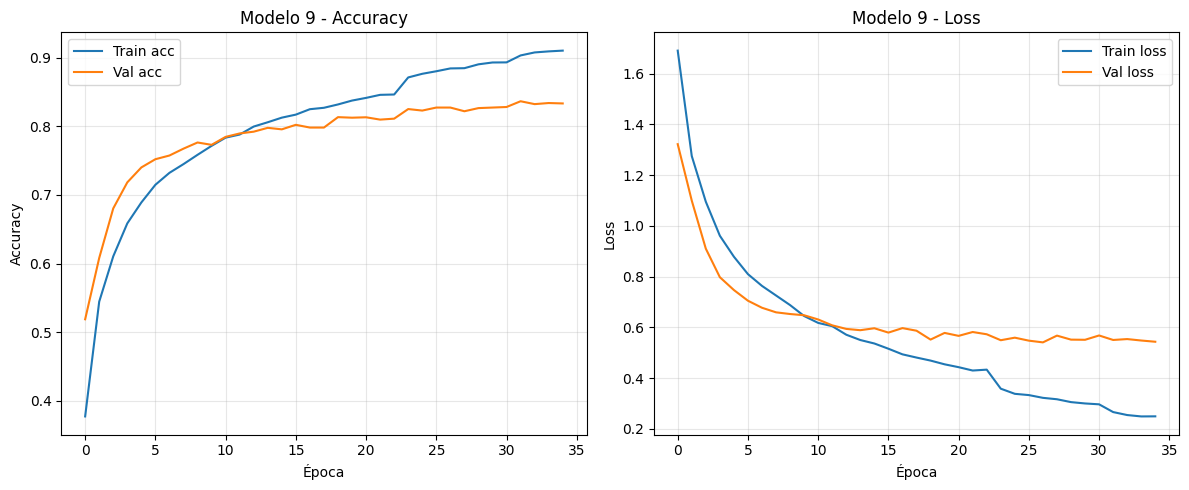

313/313 - 2s - 8ms/step - accuracy: 0.8186 - loss: 0.6031
Precisión en test (Modelo 9): 0.8186

Comparación de accuracies disponibles:
- test_acc_model8: 0.8628
- test_acc_model9: 0.8186
- test_acc_resnet: 0.8138
- test_acc_strong: 0.7813
- test_acc_model7: 0.1125


In [ ]:
# Curvas y evaluación del Modelo 9
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_model9.history['accuracy'], label='Train acc')
plt.plot(history_model9.history['val_accuracy'], label='Val acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Modelo 9 - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_model9.history['loss'], label='Train loss')
plt.plot(history_model9.history['val_loss'], label='Val loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Modelo 9 - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_model9, test_acc_model9 = model9.evaluate(test_images, test_labels, verbose=2)
print(f'Precisión en test (Modelo 9): {test_acc_model9:.4f}')

## Tabla comparativa de accuracy
Resumen final de precisión en test por modelo.

In [ ]:
import pandas as pd

rows = [
    ('Modelo 1', globals().get('test_acc', None)),
    ('Modelo 2', globals().get('test_acc_new_model', None)),
    ('Modelo 3', globals().get('test_acc_selu', None)),
    ('Modelo 4', globals().get('test_acc_modified', None)),
    ('Modelo 5', globals().get('test_acc_strong', None)),
    ('Modelo 7', globals().get('test_acc_model7', None)),
    ('Modelo 8', globals().get('test_acc_model8', None)),
    ('Modelo 9', globals().get('test_acc_model9', None)),
]

df_acc = pd.DataFrame(rows, columns=['Modelo', 'Accuracy'])
df_acc = df_acc.dropna()
df_acc['Accuracy'] = df_acc['Accuracy'].astype(float).round(4)
df_acc = df_acc.sort_values('Accuracy', ascending=False).reset_index(drop=True)

df_acc

,Modelo,Accuracy
0,Modelo 8,0.8628
1,Modelo 9,0.8186
2,Modelo 5,0.7813
3,Modelo 7,0.1125
